# Assignment 03: Cleaning Biodiversity Occurrence Data

## BIO597 Spatial Analysis of Biodiversity

This assignment reinforces the data cleaning concepts and best-practices from Lab 03.


### Example dataset: The Amphibians of the State of Maine

I downloaded all occurrence records for class **Amphibia** within a rough bounding box of the entire state of Maine. This totals 25972 records from 26 published datasets, so surely this is going to need some proper cleaning!

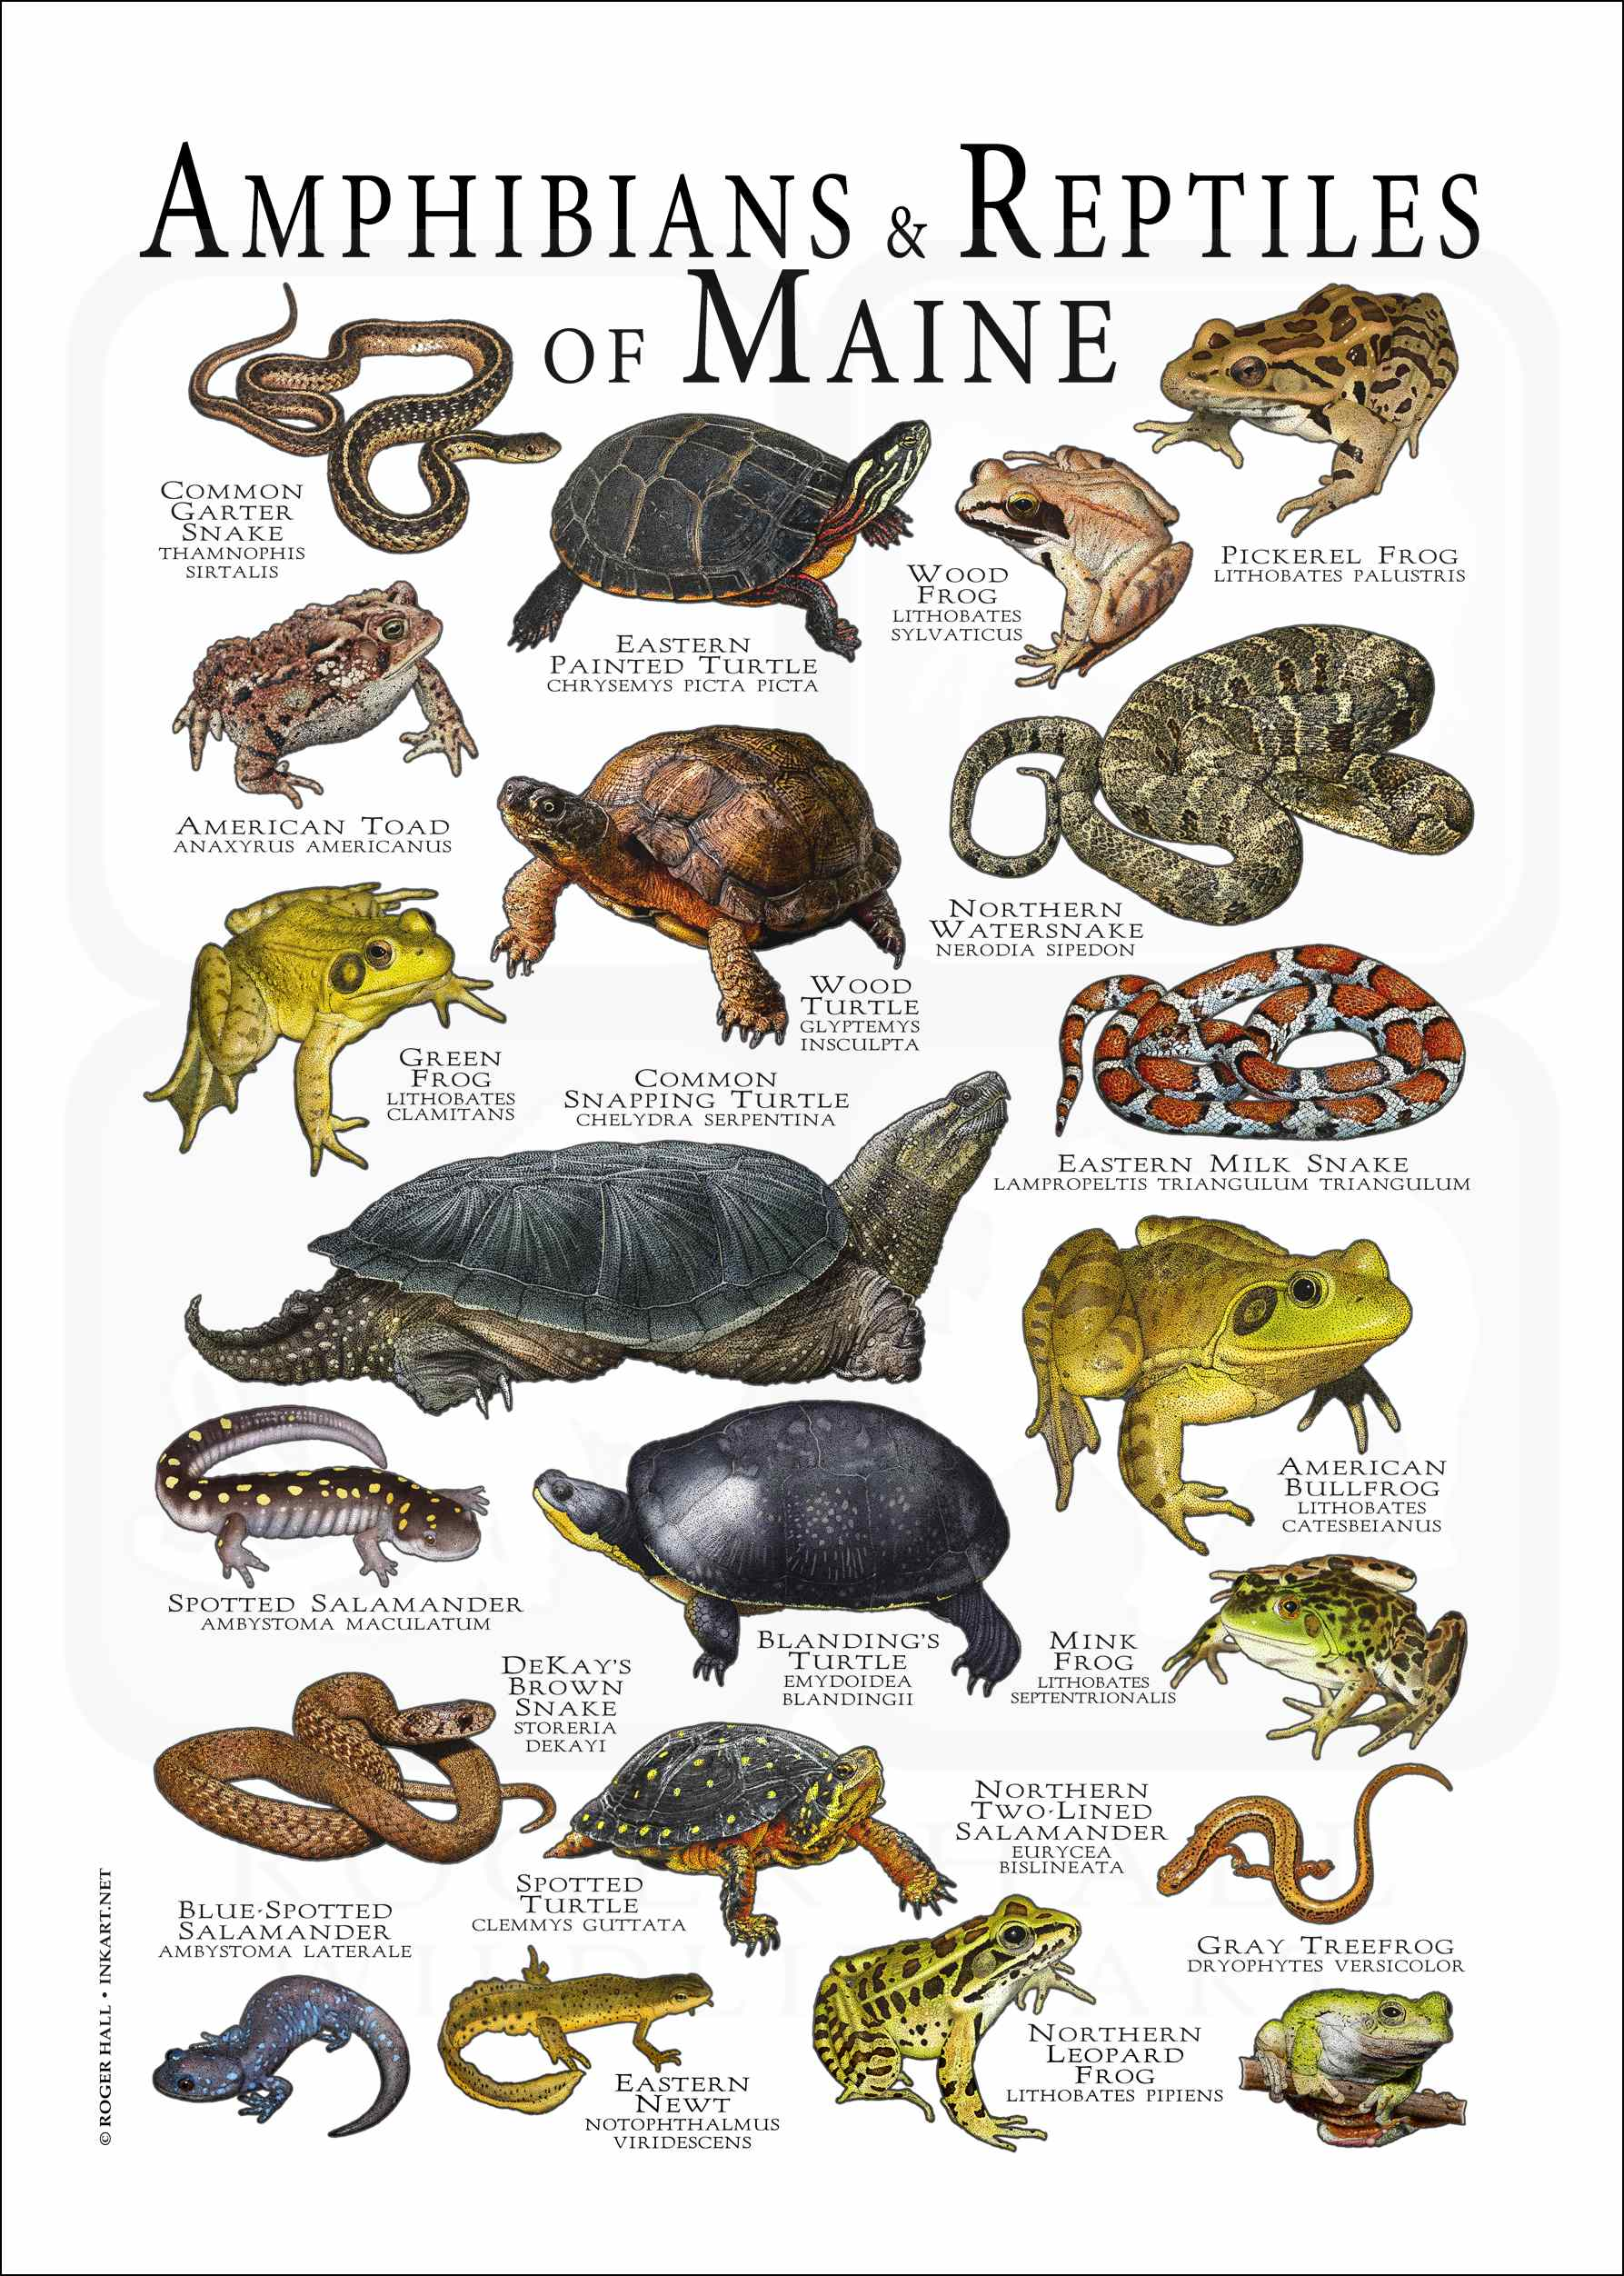

The citation for the [GBIF data](https://doi.org/10.15468/dl.27zsa8) used in this exercise is:
```
GBIF.org (16 September 2026) GBIF Occurrence Download https://doi.org/10.15468/dl.27zsa8
```

The downloaded occurrence data lives in the class github repository, and this it will be inside
your own local copy of this rep in the 'assignments' directory and then in this file:

`Amphibians_ME/Amphibians_ME.csv`

The file is tab-delimited, even though it ends in `.csv`, so remember to use `sep="\t"` when reading it.


## Goals

By the end of this assignment, you should be able to:

* load a GBIF occurrence table
* inspect species names and metadata
* remove or flag records with coordinate problems
* filter by geography, uncertainty, duplicates, and date
* convert cleaned records to a GeoDataFrame
* repeat a cleaning workflow for more than one species

The first part walks through one species with more guidance. Later sections ask you to repeat the workflow with less scaffolding.


## 1. Import packages

Use `pandas` for table operations and `geopandas` for spatial data.


In [ ]:
import pandas as pd
import geopandas as gpd

## 2. Load the amphibian records

Read the tab-delimited GBIF file and inspect the first few rows.


In [ ]:
amphibians = pd.read_csv("Amphibians_ME/Amphibians_ME.csv", sep="\t")
amphibians.head()

## 3. Inspect the size of the dataset

How many rows and columns are in the raw dataset?


In [ ]:
amphibians.shape

## 4. Count records by species

Use this table to choose species for later parts of the assignment.


In [ ]:
amphibians["species"].value_counts(dropna=False).head(20)

## 4.5 Inspect columns in the data
I get you started with some of the useful columns in this data in the next code cell,
but if there are any other columns you think could be interesting please include them
below so you can retain them for later.

In [ ]:
# Print the columns of this dataframe
amphibians.columns

## 5. Keep useful columns

Create a smaller table with columns related to identity, location, date, record type, and GBIF issue flags.

Fill in the missing column names.


In [ ]:
columns_to_keep = [
    "gbifID",
    "occurrenceID",
    "genus",
    "species",
    "scientificName",
    "countryCode",
    "stateProvince",
    "locality",
    "decimalLatitude",
    "decimalLongitude",
    "coordinateUncertaintyInMeters",
    "eventDate",
    "year",
    "basisOfRecord",
    "institutionCode",
    "collectionCode",
    "catalogNumber",
    "issue",
]

amphibians = amphibians[__________]
amphibians.head()

## 6. Start with one species

For the guided section, use American bullfrog, *Lithobates catesbeianus*.

Create a new table called `bullfrog` containing only records where the `species` column equals `Lithobates catesbeianus`.


In [ ]:
# Make a new dataframe (`bullfrog`) that contains only those records in `amphibians` that
# bullfrog scientific name in the `species` column.
# NB: The call to `.copy()` creates a brand new set of records in `bullfrog` that
#     do not refer back to the `amphibians` dataframe, so it is a copy of the data
#     rather than a 'view'. This is a technical thing that you don't have to understand so well right now.

# Fill the missing species name
bullfrog = amphibians[amphibians["species"] == "__________"].copy()
bullfrog.shape

## 7. Make numeric columns numeric

Convert latitude, longitude, coordinate uncertainty, and year to numeric values.

This is mostly filled in. Complete the missing column names.


In [ ]:
bullfrog["decimalLatitude"] = pd.to_numeric(bullfrog["decimalLatitude"], errors="coerce")
bullfrog["decimalLongitude"] = pd.to_numeric(bullfrog["decimalLongitude"], errors="coerce")
bullfrog["coordinateUncertaintyInMeters"] = pd.to_numeric(bullfrog["__________"], errors="coerce")
bullfrog["year"] = pd.to_numeric(bullfrog["__________"], errors="coerce")

bullfrog[["decimalLatitude", "decimalLongitude", "coordinateUncertaintyInMeters", "year"]].head()

## 8. Check for missing coordinates

Count records where latitude or longitude is missing.


In [ ]:
missing_coordinates = bullfrog[
    bullfrog["decimalLatitude"].isna() | bullfrog["decimalLongitude"].isna()
]

missing_coordinates.shape

## 9. Remove missing coordinates

Create `bullfrog_clean` by dropping records with missing latitude or longitude.


In [ ]:
bullfrog_clean = bullfrog.dropna(subset=["__________", "__________"]).copy()
bullfrog_clean.shape

## 10. Check whether records are in Maine

These data are intended to represent amphibian records from Maine. Use a broad Maine bounding box:

* latitude between 42.9 and 47.5
* longitude between -71.2 and -66.8

Create a Boolean variable called `in_maine_box`.


In [ ]:
in_maine_box = (
    bullfrog_clean["decimalLatitude"].between(__________, __________)
    & bullfrog_clean["decimalLongitude"].between(__________, __________)
)

bullfrog_clean[~in_maine_box][
    ["gbifID", "species", "stateProvince", "decimalLatitude", "decimalLongitude", "locality"]
].head(20)

## 11. Keep records inside the Maine bounding box

Apply the geographic filter and check how many bullfrog records remain.


In [ ]:
bullfrog_clean = bullfrog_clean[in_maine_box].copy()
bullfrog_clean.shape

## 12. Inspect coordinate uncertainty

Look at the most common coordinate uncertainty values for bullfrog records.


In [ ]:
bullfrog_clean["coordinateUncertaintyInMeters"].value_counts(dropna=False).head(15)

## 13. Remove records with high coordinate uncertainty

For this assignment, remove records with coordinate uncertainty greater than 1,000 m. Keep records where coordinate uncertainty is missing.

Fill in the missing threshold.


In [ ]:
bullfrog_clean = bullfrog_clean[
    bullfrog_clean["coordinateUncertaintyInMeters"].isna()
    | (bullfrog_clean["coordinateUncertaintyInMeters"] <= __________)
].copy()

bullfrog_clean.shape

## 14. Remove simple duplicates

Drop records with the same species, latitude, longitude, and year.


In [ ]:
bullfrog_clean = bullfrog_clean.drop_duplicates(
    subset=["species", "decimalLatitude", "decimalLongitude", "year"]
).copy()

bullfrog_clean.shape

## 15. Filter by year

Keep records from 2000 onward. This is an example cutoff; in a real project the cutoff should match your research question.


In [ ]:
bullfrog_clean = bullfrog_clean[
    bullfrog_clean["year"].notna()
    & (bullfrog_clean["year"] >= __________)
].copy()

bullfrog_clean.shape

## 16. Convert cleaned bullfrog records to a GeoDataFrame

Use `gpd.points_from_xy()` to create point geometry.


In [ ]:
bullfrog_gdf = gpd.GeoDataFrame(
    bullfrog_clean,
    geometry=gpd.points_from_xy(bullfrog_clean["__________"], bullfrog_clean["__________"]),
    crs="EPSG:4326",
)

bullfrog_gdf.head()

## 17. Map the cleaned bullfrog records

Use `.explore()` to map the cleaned points.


In [ ]:
__________.explore()

## 18. Review the GBIF issue flags

Look at the issue flags that remain after cleaning. Remember: not every issue means a record is unusable.


In [ ]:
bullfrog_gdf["issue"].value_counts(dropna=False).head(15)

## 19. Choose two more species

Choose two additional species from the species count table near the beginning of the assignment.

Write their names below.

**Species 1:**

**Species 2:**


## 20. Repeat the cleaning workflow for species 1

Create a new table for your first chosen species and apply these steps:

1. subset to one species
2. convert coordinate, uncertainty, and year columns to numeric
3. remove missing coordinates
4. keep records inside the Maine bounding box
5. remove records with coordinate uncertainty greater than 1,000 m, while keeping missing uncertainty
6. remove duplicate species-coordinate-year records
7. keep records from 2000 onward
8. convert to a GeoDataFrame
9. map the cleaned records

Use clear variable names so you know which species you are working with.


In [ ]:
# Write your species 1 cleaning workflow here.


## 21. Repeat the cleaning workflow for species 2

Now repeat the same workflow for your second chosen species. Try to copy, paste, and carefully modify your previous code.


In [ ]:
# Write your species 2 cleaning workflow here.


## 22. Combine your cleaned GeoDataFrames

Combine your cleaned bullfrog GeoDataFrame with the two cleaned GeoDataFrames you created.

Fill in the variable names for your two additional species.


In [ ]:
cleaned_amphibians = pd.concat([bullfrog_gdf, __________, __________])
cleaned_amphibians.shape

## 23. Map the cleaned records by species

Color the cleaned records by species.


In [ ]:
cleaned_amphibians.explore(column="__________", cmap="rainbow")

## 24. Summarize records by species

Count how many cleaned records remain for each species.


In [ ]:
cleaned_amphibians["__________"].value_counts(dropna=False)

## 25. Reflection questions

Answer these questions after completing your cleaning workflow.

**Question 1:** Which cleaning step removed the most records for your species?

**Your answer:**

**Question 2:** Which cleaning decision felt most subjective? Why?

**Your answer:**

**Question 3:** Would you keep records with missing coordinate uncertainty for a species distribution model? Why or why not?

**Your answer:**

**Question 4:** How could cleaning choices change the biological interpretation of a species map?

**Your answer:**


## 26. Submit your work

Before submitting, make sure you have run the notebook from top to bottom and answered the written questions.

Commit and push your completed notebook to your class GitHub repository.

Open a terminal window and run these commands to add, commit, and push your notebook:

    # Go to the labs directory in the course repo
    cd ~/BIO597-SpatialBiodiversity/docs/assignments
    
    # Add your changed lab
    git add Assignment-03-DataCleaning.ipynb
    git commit -m 'Finished Assignment-03'
    git push